In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df=pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

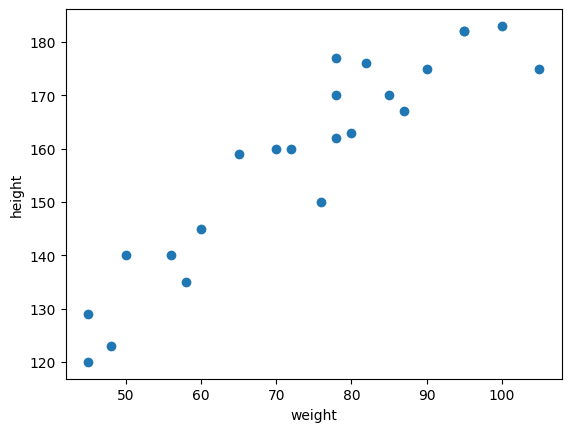

In [4]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("weight")
plt.ylabel("height")

In [5]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


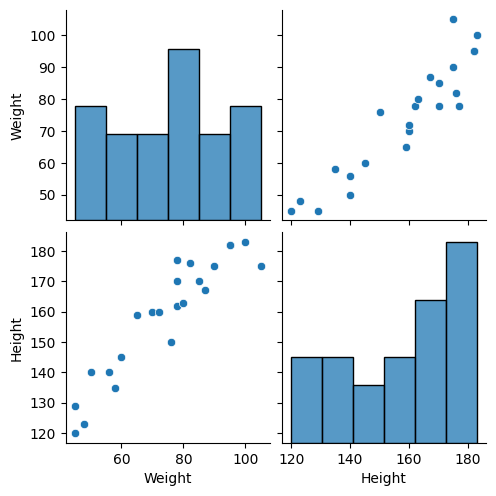

In [6]:
import seaborn as sns
sns.pairplot(df)

In [7]:
x=df[['Weight']]
y=df['Height']

In [8]:
x_series=df['Weight']
np.array(x_series).shape

(23,)

In [9]:
np.array(y).shape

(23,)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)

In [13]:

x_test=scaler.transform(x_test)

In [14]:
x_test

array([[ 0.21043706],
       [ 0.21043706],
       [-1.6552288 ],
       [ 1.17153765],
       [-0.52452222]])

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
regression=LinearRegression(n_jobs=-1)

In [17]:
regression.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [18]:
print("Coefficient or slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or slope: [17.03440872]
Intercept: 157.5


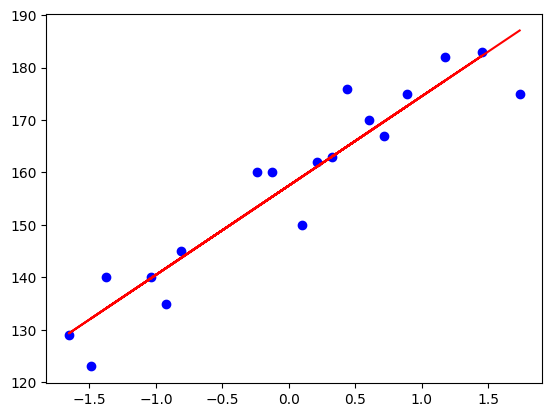

In [19]:
plt.scatter(x_train,y_train,color='blue')
plt.plot(x_train,regression.predict(x_train),color='red')

In [20]:
y_pred=regression.predict(x_test)
y_pred

array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
       148.56507414])

In [21]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [22]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
mse,mae,rmse


(109.77592599051664, 9.822657814519232, np.float64(10.477400726827081))

In [23]:
from sklearn.metrics import r2_score

In [24]:
score=r2_score(y_test,y_pred)
score

0.776986986042344

In [25]:
1 - (1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.7026493147231252

In [29]:
import statsmodels.api as sm

In [30]:
model=sm.OLS(y_train,x_train).fit()

In [31]:
predictions=model.predict(x_test)
print(predictions)

[  3.58467086   3.58467086 -28.1958439   19.95645118  -8.93492586]


In [32]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.047
Method:                 Least Squares   F-statistic:                             0.1986
Date:                Mon, 16 Mar 2026   Prob (F-statistic):                       0.661
Time:                        00:44:23   Log-Likelihood:                         -116.62
No. Observations:                  18   AIC:                                      235.2
Df Residuals:                      17   BIC:                                      236.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\ravin\anaconda3\envs\ml_env\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [33]:
regression.predict(scaler.transform([[150]]))

c:\Users\ravin\anaconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([230.42397577])